<a href="https://colab.research.google.com/github/manoviraj123/BDA-ASSIGNMENT2_134/blob/main/BDA_ASSINGMENT_134.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:

!pip install -q findspark

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("BDA_Assignment").getOrCreate()

print("Spark Installed Successfully!")

Spark Installed Successfully!


## **1. CLASSIFICATION (Iris + Metrics + Visualization)**

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| setosa|
|         4.9|        3.0|         1.4|        0.2| setosa|
|         4.7|        3.2|         1.3|        0.2| setosa|
|         4.6|        3.1|         1.5|        0.2| setosa|
|         5.0|        3.6|         1.4|        0.2| setosa|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows
+-----------------+-----+----------+
|         features|label|prediction|
+-----------------+-----+----------+
|[4.4,3.0,1.3,0.2]|  0.0|       0.0|
|[4.6,3.2,1.4,0.2]|  0.0|       0.0|
|[4.6,3.6,1.0,0.2]|  0.0|       0.0|
|[4.8,3.1,1.6,0.2]|  0.0|       0.0|
|[4.9,3.1,1.5,0.1]|  0.0|       0.0|
|[5.0,2.3,3.3,1.0]|  1.0|       1.0|
|[5.0,3.5,1.3,0.3]|  0.0|       0.0|
|[5.1,3.5,1.4,0.2]|  0.0|       0.0|
|[5.3,3.7,1.5,0.2]|  0.0|    

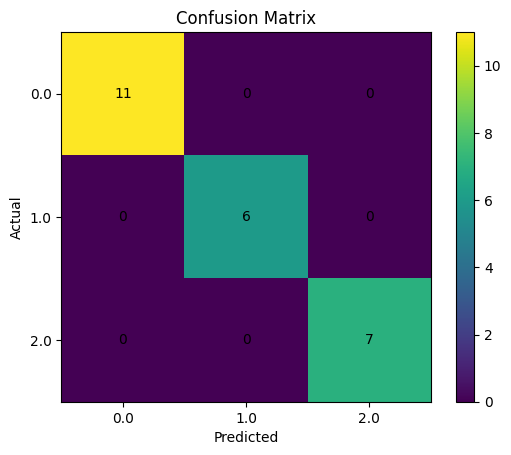

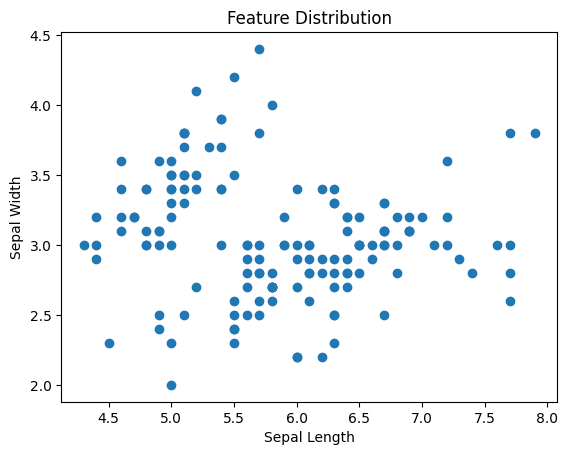

In [6]:
import requests

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
response = requests.get(url)
with open("iris.csv", "w") as f:
    f.write(response.text)

df = spark.read.csv("iris.csv", header=True, inferSchema=True)

df.show(5)
from pyspark.ml.feature import VectorAssembler, StringIndexer

assembler = VectorAssembler(
    inputCols=["sepal_length","sepal_width","petal_length","petal_width"],
    outputCol="features"
)
data = assembler.transform(df)

indexer = StringIndexer(inputCol="species", outputCol="label")
data = indexer.fit(data).transform(data).select("features","label")


train, test = data.randomSplit([0.8, 0.2], seed=42)

from pyspark.ml.classification import LogisticRegression
model = LogisticRegression().fit(train)

pred = model.transform(test)

pred.select("features","label","prediction").show()


from pyspark.ml.evaluation import MulticlassClassificationEvaluator

accuracy = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
).evaluate(pred)

precision = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
).evaluate(pred)

recall = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall"
).evaluate(pred)

f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
).evaluate(pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


import matplotlib.pyplot as plt
import pandas as pd

pdf = pred.select("label","prediction").toPandas()

cm = pd.crosstab(pdf['label'], pdf['prediction'])
print("\nConfusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(range(len(cm.columns)), cm.columns)
plt.yticks(range(len(cm.index)), cm.index)

for i in range(len(cm.index)):
    for j in range(len(cm.columns)):
        plt.text(j, i, cm.iloc[i, j], ha='center', va='center')

plt.colorbar()
plt.show()


pdf_full = df.toPandas()

plt.figure()
plt.scatter(pdf_full["sepal_length"], pdf_full["sepal_width"])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Feature Distribution")
plt.show()

## **2. CLUSTERING (K-Means + Metrics + Visualization + Elbow)**

+----------+------+---+------------------+----------------------+
|CustomerID| Genre|Age|Annual Income (k$)|Spending Score (1-100)|
+----------+------+---+------------------+----------------------+
|         1|  Male| 19|                15|                    39|
|         2|  Male| 21|                15|                    81|
|         3|Female| 20|                16|                     6|
|         4|Female| 23|                16|                    77|
|         5|Female| 31|                17|                    40|
+----------+------+---+------------------+----------------------+
only showing top 5 rows
root
 |-- CustomerID: integer (nullable = true)
 |-- Genre: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Annual Income (k$): integer (nullable = true)
 |-- Spending Score (1-100): integer (nullable = true)

+---+-------------+--------------+----------+
|Age|Annual_Income|Spending_Score|prediction|
+---+-------------+--------------+----------+
| 19|           

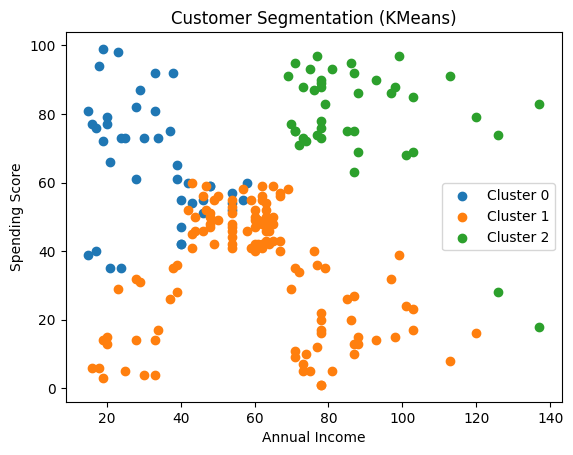

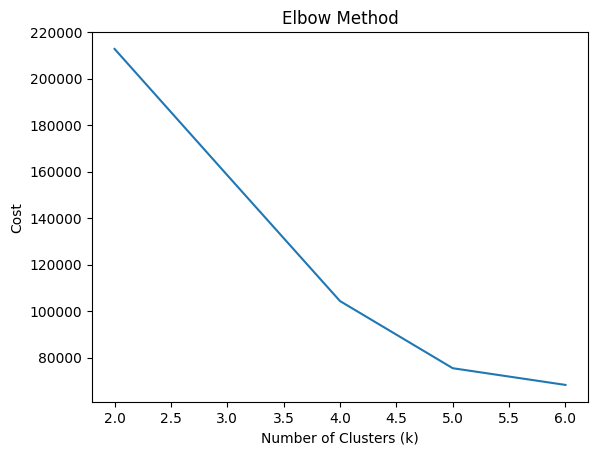

In [16]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import pandas as pd

df = spark.read.csv("/content/Mall_Customers.csv", header=True, inferSchema=True)

df.show(5)
df.printSchema()


df = df.withColumnRenamed("Annual Income (k$)", "Annual_Income") \
       .withColumnRenamed("Spending Score (1-100)", "Spending_Score")


assembler = VectorAssembler(
    inputCols=["Age","Annual_Income","Spending_Score"],
    outputCol="features"
)
data = assembler.transform(df)


kmeans = KMeans(k=3, seed=1)
model = kmeans.fit(data)

pred = model.transform(data)
pred.select("Age","Annual_Income","Spending_Score","prediction").show()


evaluator = ClusteringEvaluator()
silhouette = evaluator.evaluate(pred)

print("Silhouette Score:", silhouette)


centers = model.clusterCenters()
print("\nCluster Centers:")
for i, center in enumerate(centers):
    print(f"Cluster {i}: {center}")


pdf = pred.select("Age","Annual_Income","Spending_Score","prediction").toPandas()

plt.figure()
for cluster in sorted(pdf['prediction'].unique()):
    subset = pdf[pdf['prediction'] == cluster]
    plt.scatter(subset["Annual_Income"], subset["Spending_Score"], label=f"Cluster {cluster}")

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation (KMeans)")
plt.legend()
plt.show()


cost = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(k=k, seed=1)
    m = km.fit(data)
    cost.append(m.summary.trainingCost)

plt.figure()
plt.plot(k_values, cost)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Cost")
plt.title("Elbow Method")
plt.show()

## **3. RECOMMENDATION SYSTEM (Goodbooks + RMSE + Visualization)**


+-------+-------+------+
|user_id|book_id|rating|
+-------+-------+------+
|      1|    258|     5|
|      2|   4081|     4|
|      2|    260|     5|
|      2|   9296|     5|
|      2|   2318|     3|
+-------+-------+------+
only showing top 5 rows
root
 |-- user_id: integer (nullable = true)
 |-- book_id: integer (nullable = true)
 |-- rating: integer (nullable = true)

+-------+-------+------+----------+
|user_id|book_id|rating|prediction|
+-------+-------+------+----------+
|    463|     10|     5| 3.7062888|
|    463|     27|     3| 3.6971292|
|    463|     28|     2| 3.0790615|
|    463|     32|     2|  3.252024|
|    463|     39|     1| 3.7879384|
+-------+-------+------+----------+
only showing top 5 rows
RMSE: 0.8189783720101792
+-------+-----------------------------------------------------------------------------------------------+
|user_id|recommendations                                                                                |
+-------+--------------------------------

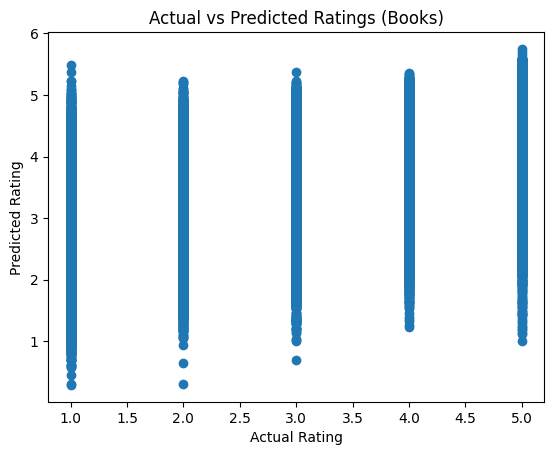

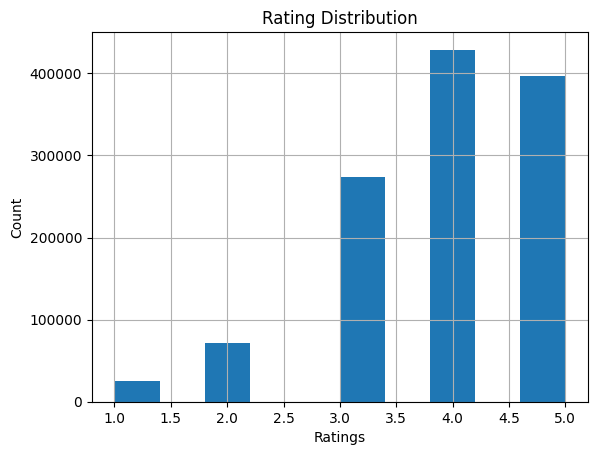

In [18]:

import requests

url = "https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master/ratings.csv"


response = requests.get(url)
with open("ratings.csv", "w") as f:
    f.write(response.text)

ratings = spark.read.csv("ratings.csv", header=True, inferSchema=True)

ratings.show(5)
ratings.printSchema()


train, test = ratings.randomSplit([0.8, 0.2], seed=42)


from pyspark.ml.recommendation import ALS

als = ALS(
    userCol="user_id",
    itemCol="book_id",
    ratingCol="rating",
    coldStartStrategy="drop"
)

model = als.fit(train)


pred = model.transform(test)
pred.show(5)


from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

rmse = evaluator.evaluate(pred)
print("RMSE:", rmse)


recs = model.recommendForAllUsers(5)
recs.show(truncate=False)


import matplotlib.pyplot as plt
import pandas as pd

pdf = pred.select("rating", "prediction").toPandas()

plt.figure()
plt.scatter(pdf["rating"], pdf["prediction"])
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings (Books)")
plt.show()


plt.figure()
pdf["rating"].hist()
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()